In [ ]:
# =========================
# 1. Install Required Libraries
# =========================
!pip install -q kaggle xgboost

# =========================
# 2. Upload kaggle.json
# =========================
from google.colab import files
files.upload()

# =========================
# 3. Setup Kaggle API
# =========================
import os
import zipfile

os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

# =========================
# 4. Download Dataset
# =========================
!kaggle datasets download -d naiyakhalid/flood-prediction-dataset

# =========================
# 5. Extract Dataset
# =========================
with zipfile.ZipFile("flood-prediction-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

# =========================
# 6. Load Dataset
# =========================
import pandas as pd

df = pd.read_csv("data/flood.csv")   # Adjust name if needed
df.head()


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/naiyakhalid/flood-prediction-dataset
License(s): CC0-1.0
  0% 0.00/28.6M [00:00<?, ?B/s]
100% 28.6M/28.6M [00:00<00:00, 1.23GB/s]


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 1. Load Train and Test
# =========================
train_df = pd.read_csv("data/train.csv")

print("TRAIN DATA")
display(train_df.head())

TRAIN DATA


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [ ]:
len(train_df)

1117957

In [ ]:

test_df = pd.read_csv("data/flood.csv")

# =========================
# 2. Drop ID Column (if exists)
# =========================
if "id" in train_df.columns:
    train_df = train_df.drop("id", axis=1)

if "id" in test_df.columns:
    test_df = test_df.drop("id", axis=1)

# =========================
# 3. Separate Features & Target
# =========================
X_train = train_df.drop("FloodProbability", axis=1)
y_train = train_df["FloodProbability"]

X_test = test_df.drop("FloodProbability", axis=1)
y_test = test_df["FloodProbability"]

# =========================
# 4. Train Model
# =========================
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================
# 5. Predict
# =========================
y_pred = model.predict(X_test)

# =========================
# 6. Evaluate
# =========================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Flood.csv RMSE:", rmse)
print("Flood.csv R2 Score:", r2)


Flood.csv RMSE: 0.011875352596356968
Flood.csv R2 Score: 0.9436668032384458


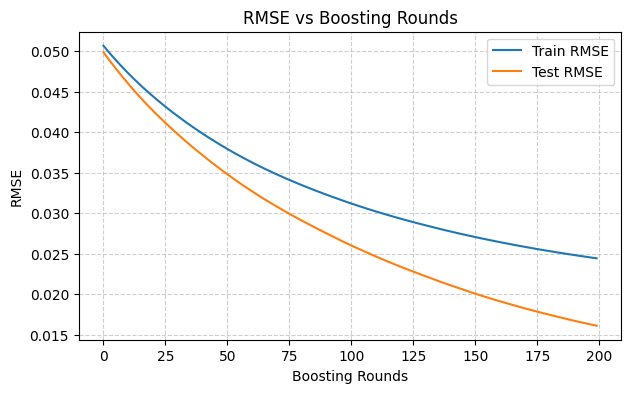

In [ ]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='rmse'   # <-- MOVED HERE (IMPORTANT)
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# Get evaluation history
results = model.evals_result()
epochs = range(len(results['validation_0']['rmse']))

# Plot RMSE curve
plt.figure(figsize=(7,4))
plt.plot(epochs, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(epochs, results['validation_1']['rmse'], label='Test RMSE')

plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('RMSE vs Boosting Rounds')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

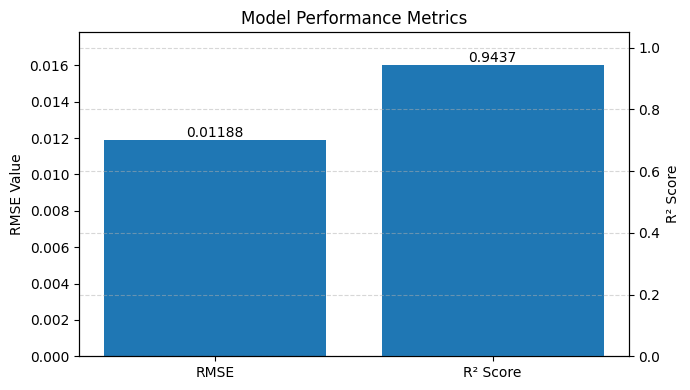

In [ ]:
import matplotlib.pyplot as plt

rmse = 0.011875352596356968
r2 = 0.9436668032384458

fig, ax1 = plt.subplots(figsize=(7,4))

# RMSE bar (left axis)
ax1.bar('RMSE', rmse)
ax1.set_ylabel('RMSE Value')
ax1.set_ylim(0, rmse * 1.5)

# R2 bar (right axis)
ax2 = ax1.twinx()
ax2.bar('R² Score', r2)
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1.05)

# Value labels
ax1.text(0, rmse, f'{rmse:.5f}', ha='center', va='bottom')
ax2.text(1, r2, f'{r2:.4f}', ha='center', va='bottom')

plt.title('Model Performance Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()